<a href="https://colab.research.google.com/github/NETSADOM/Enzyme-Function-Classification-from-Protein-Sequence-/blob/main/Enzyme_Function_Classification_from_Protein_Sequence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets lightgbm imbalanced-learn shap scikit-learn matplotlib seaborn gensim xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 75.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import re
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, matthews_corrcoef, accuracy_score, average_precision_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
from gensim.models import Word2Vec
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')


In [ ]:
print("Loading dataset...")
dataset = load_dataset("DanielHesslow/SwissProt-EC")
df = pd.DataFrame(dataset['train'])
print(f"Loaded Hugging Face dataset. Shape: {df.shape}")

Loading dataset...


README.md:   0%|          | 0.00/522 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 85.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/dev-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/208823 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25892 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/26724 [00:00<?, ? examples/s]

Loaded Hugging Face dataset. Shape: (208823, 4)


In [ ]:
print("Original dataset size:", len(df))
print("Original Class distribution:")
def extract_first_ec(ec_string):
    if pd.isna(ec_string):
        return None
    if isinstance(ec_string, list):
        if len(ec_string) > 0:
            ec = ec_string[0]
        else:
            return None
    else:
        ec = str(ec_string)

    match = re.search(r'EC:(\d+)', ec)
    if match:
        digit = int(match.group(1))
        if 1 <= digit <= 6:
            return digit
    return None

df['EC1'] = df['labels_str'].apply(extract_first_ec)
df = df.dropna(subset=['EC1'])
df['EC1'] = df['EC1'].astype(int)
print(df['EC1'].value_counts())

missing_seqs = df['seq'].isna() | (df['seq'].str.strip() == '')
print(f"\nRemoving {missing_seqs.sum()} missing or empty sequences.")
df = df[~missing_seqs].copy()

num_duplicates = df.duplicated(subset=['seq']).sum()
print(f"Removing {num_duplicates} duplicate sequences.")
df = df.drop_duplicates(subset=['seq']).copy()

df['seq_len'] = df['seq'].apply(len)
print("\nSequence length statistics before cleaning:")
print(df['seq_len'].describe())

non_standard_mask = df['seq'].str.contains(r'[^ACDEFGHIKLMNPQRSTVWY]', case=False)
print(f"\nFound {non_standard_mask.sum()} sequences with non-standard characters.")


print("Cleaning sequences (removing non-standard characters)...")
df['seq'] = df['seq'].apply(lambda x: re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', str(x).upper()))

empty_seqs_after = df['seq'].str.strip() == ''
print(f"Removing {empty_seqs_after.sum()} sequences that became empty after cleaning.")
df = df[~empty_seqs_after].copy()

df['seq_len'] = df['seq'].apply(len)
print("\nSequence length statistics after cleaning:")
print(df['seq_len'].describe())

print(f"\nDataset size after cleaning: {len(df)}")
print("Class distribution after cleaning:")
print(df['EC1'].value_counts())

SAMPLE_SIZE = 10000
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"\nSampled down to {SAMPLE_SIZE} for feasible processing time in this session.")
    print("Class distribution after sampling:")
    print(df['EC1'].value_counts())

Original dataset size: 169682
Original Class distribution:
EC1
2    62824
3    40306
1    22300
6    19481
4    15671
5     9100
Name: count, dtype: int64

Removing 0 missing or empty sequences.
Removing 0 duplicate sequences.

Sequence length statistics before cleaning:
count    169682.000000
mean        426.438008
std         338.360570
min          30.000000
25%         259.000000
50%         357.000000
75%         489.000000
max       35213.000000
Name: seq_len, dtype: float64

Found 0 sequences with non-standard characters.
Cleaning sequences (removing non-standard characters)...
Removing 0 sequences that became empty after cleaning.

Sequence length statistics after cleaning:
count    169682.000000
mean        426.438008
std         338.360570
min          30.000000
25%         259.000000
50%         357.000000
75%         489.000000
max       35213.000000
Name: seq_len, dtype: float64

Dataset size after cleaning: 169682
Class distribution after cleaning:
EC1
2    62824
3    403

In [ ]:
X = df['seq'].values
y = df['EC1'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (7000,)
Validation shape: (1500,)
Test shape: (1500,)


Extracting AAC and DPC features...
Extracting Tripeptide 3-mers...
Applying SelectKBest Feature Selection on Tripeptides...
Applying TruncatedSVD Embedding...
Training Word2Vec embeddings on 3-mers...
Applying Embedding...
Computing Cosine Similarity between Class Centroids (using Word2Vec embeddings)...


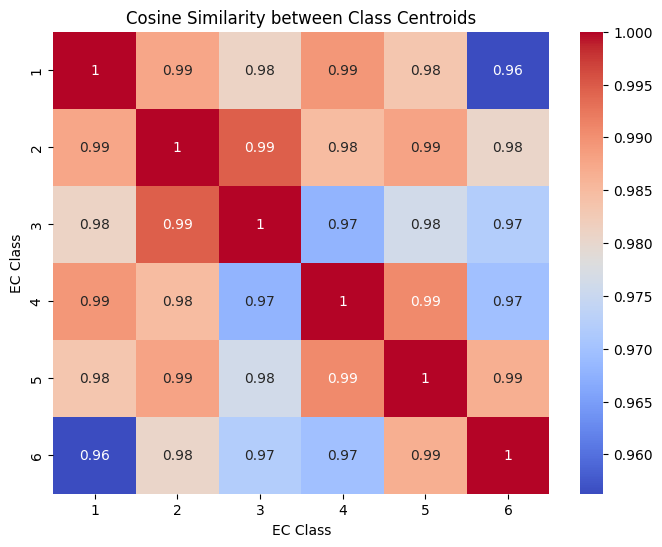

Final Train feature shape: (7000, 712)


In [ ]:
from itertools import product
from sklearn.feature_extraction.text import CountVectorizer

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
dipeptides = [''.join(p) for p in product(amino_acids, repeat=2)]
tripeptides = [''.join(p) for p in product(amino_acids, repeat=3)]

def calculate_aac(seq):
    counts = Counter(seq)
    length = len(seq) if len(seq) > 0 else 1
    return [counts.get(aa, 0) / length for aa in amino_acids]

def calculate_dpc(seq):
    length = len(seq) - 1 if len(seq) > 1 else 1
    di_counts = Counter([seq[i:i+2] for i in range(len(seq)-1)])
    return [di_counts.get(dp, 0) / length for dp in dipeptides]

def extract_standard_features(sequences):
    features = []
    for seq in sequences:
        aac = calculate_aac(seq)
        dpc = calculate_dpc(seq)
        features.append(aac + dpc)
    return np.array(features)

print("Extracting AAC and DPC features...")
X_train_std = extract_standard_features(X_train)
X_val_std = extract_standard_features(X_val)
X_test_std = extract_standard_features(X_test)

def get_kmers(seq, k=3):
    return ' '.join([seq[i:i+k] for i in range(len(seq)-k+1) if len(seq) >= k])

print("Extracting Tripeptide 3-mers...")
X_train_3mers = [get_kmers(seq) for seq in X_train]
X_val_3mers = [get_kmers(seq) for seq in X_val]
X_test_3mers = [get_kmers(seq) for seq in X_test]


vectorizer = CountVectorizer(vocabulary=tripeptides, lowercase=False)
X_train_tri_counts = vectorizer.fit_transform(X_train_3mers)
X_val_tri_counts = vectorizer.transform(X_val_3mers)
X_test_tri_counts = vectorizer.transform(X_test_3mers)

print("Applying SelectKBest Feature Selection on Tripeptides...")
selector = SelectKBest(score_func=mutual_info_classif, k=100)
X_train_tri_sel = selector.fit_transform(X_train_tri_counts, y_train)
X_val_tri_sel = selector.transform(X_val_tri_counts)
X_test_tri_sel = selector.transform(X_test_tri_counts)

print("Applying TruncatedSVD Embedding...")
svd = TruncatedSVD(n_components=128, random_state=42)
X_train_embed = svd.fit_transform(X_train_tri_counts)
X_val_embed = svd.transform(X_val_tri_counts)
X_test_embed = svd.transform(X_test_tri_counts)


X_train_tri_sel_dense = X_train_tri_sel.toarray() if hasattr(X_train_tri_sel, 'toarray') else X_train_tri_sel
X_val_tri_sel_dense = X_val_tri_sel.toarray() if hasattr(X_val_tri_sel, 'toarray') else X_val_tri_sel
X_test_tri_sel_dense = X_test_tri_sel.toarray() if hasattr(X_test_tri_sel, 'toarray') else X_test_tri_sel


print("Training Word2Vec embeddings on 3-mers...")
w2v_train_tokens = [seq.split() for seq in X_train_3mers]
w2v_val_tokens = [seq.split() for seq in X_val_3mers]
w2v_test_tokens = [seq.split() for seq in X_test_3mers]

w2v_model = Word2Vec(sentences=w2v_train_tokens, vector_size=64, window=5, min_count=1, workers=4)

def get_sequence_embedding(tokens, model, vector_size):
    embeddings = [model.wv[token] for token in tokens if token in model.wv]
    if len(embeddings) > 0:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(vector_size)

print("Applying Embedding...")
X_train_w2v = np.array([get_sequence_embedding(tokens, w2v_model, 64) for tokens in w2v_train_tokens])
X_val_w2v = np.array([get_sequence_embedding(tokens, w2v_model, 64) for tokens in w2v_val_tokens])
X_test_w2v = np.array([get_sequence_embedding(tokens, w2v_model, 64) for tokens in w2v_test_tokens])

print("Computing Cosine Similarity between Class Centroids (using Word2Vec embeddings)...")
centroids = []
for c in range(6):
    class_idx = np.where(y_train == c)[0]
    class_embeddings = X_train_w2v[class_idx]
    centroids.append(np.mean(class_embeddings, axis=0))

centroids = np.array(centroids)
cos_sim_matrix = cosine_similarity(centroids)

plt.figure(figsize=(8,6))
sns.heatmap(cos_sim_matrix, annot=True, cmap='coolwarm', xticklabels=[1,2,3,4,5,6], yticklabels=[1,2,3,4,5,6])
plt.title('Cosine Similarity between Class Centroids')
plt.xlabel('EC Class')
plt.ylabel('EC Class')
plt.show()


X_train_final = np.hstack((X_train_std, X_train_tri_sel_dense, X_train_embed, X_train_w2v))
X_val_final = np.hstack((X_val_std, X_val_tri_sel_dense, X_val_embed, X_val_w2v))
X_test_final = np.hstack((X_test_std, X_test_tri_sel_dense, X_test_embed, X_test_w2v))

print("Final Train feature shape:", X_train_final.shape)


In [ ]:
print("Class distribution in training set:", Counter(y_train))
print("SMOTE will be applied within the cross-validation pipeline to prevent data leakage.")


Class distribution in training set: Counter({np.int64(1): 2571, np.int64(2): 1698, np.int64(0): 949, np.int64(5): 802, np.int64(3): 624, np.int64(4): 356})
SMOTE will be applied within the cross-validation pipeline to prevent data leakage.


In [ ]:

print("Training Random Forest...")
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])
rf_params = {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10, 20]}
rf_model = RandomizedSearchCV(rf_pipeline, rf_params, cv=5, n_iter=3, scoring='f1_macro', random_state=42)
rf_model.fit(X_train_final, y_train)
print("Best RF params:", rf_model.best_params_)

print("\nTraining LightGBM...")
lgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))
])
lgb_params = {'model__n_estimators': [100, 200], 'model__learning_rate': [0.01, 0.1]}
lgb_model = RandomizedSearchCV(lgb_pipeline, lgb_params, cv=5, n_iter=3, scoring='f1_macro', random_state=42)
lgb_model.fit(X_train_final, y_train)
print("Best LGBM params:", lgb_model.best_params_)

print("\nTraining SVM...")
svm_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(probability=True, random_state=42, class_weight='balanced'))
])
svm_params = {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf', 'linear']}
# Scale down sample for SVM tuning if dataset is large
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_train_final), min(3000, len(X_train_final)), replace=False)
svm_model = RandomizedSearchCV(svm_pipeline, svm_params, cv=5, n_iter=2, scoring='f1_macro', random_state=42)
svm_model.fit(X_train_final[sample_idx], y_train[sample_idx])
print("Best SVM params:", svm_model.best_params_)

print("\nTraining MLP Neural Network...")
mlp_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', MLPClassifier(random_state=42, max_iter=200))
])
mlp_params = {'model__hidden_layer_sizes': [(64,), (128, 64)], 'model__alpha': [0.0001, 0.001]}
mlp_model = RandomizedSearchCV(mlp_pipeline, mlp_params, cv=5, n_iter=2, scoring='f1_macro', random_state=42)
mlp_model.fit(X_train_final, y_train)
print("Best MLP params:", mlp_model.best_params_)

print("\nTraining XGBoost...")
xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'))
])
xgb_params = {'model__n_estimators': [100], 'model__max_depth': [3, 6]}
xgb_model = RandomizedSearchCV(xgb_pipeline, xgb_params, cv=5, n_iter=2, scoring='f1_macro', random_state=42)
xgb_model.fit(X_train_final, y_train)
print("Best XGB params:", xgb_model.best_params_)

Training Random Forest...
Best RF params: {'model__n_estimators': 200, 'model__max_depth': None}

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.177316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180491
[LightGBM] [Info] Number of data points in the train set: 12342, number of used features: 712
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.215658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180515
[LightGBM] [Info] Number of data points in the train set: 12342, nu

In [ ]:

best_rf = rf_model.best_estimator_
best_lgb = lgb_model.best_estimator_
best_svm = svm_model.best_estimator_
best_mlp = mlp_model.best_estimator_
best_xgb = xgb_model.best_estimator_

estimators_list = [
    ('rf', best_rf),
    ('lgb', best_lgb),
    ('svm', best_svm),
    ('mlp', best_mlp),
    ('xgb', best_xgb)
]

print("Training Hard Voting Ensemble...")
hard_voting = VotingClassifier(estimators=estimators_list, voting='hard')
hard_voting.fit(X_train_final, y_train)

print("Training Soft Voting Ensemble...")
soft_voting = VotingClassifier(estimators=estimators_list, voting='soft')
soft_voting.fit(X_train_final, y_train)

print("Training Stacking Ensemble...")
stacking = StackingClassifier(
    estimators=estimators_list,
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000),
    cv=5
)
stacking.fit(X_train_final, y_train)


Training Hard Voting Ensemble...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.184888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180633
[LightGBM] [Info] Number of data points in the train set: 15426, number of used features: 712
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Training Soft Voting Ensemble...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.183001 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180633
[LightGBM] [Info] Number of data points in the train set: 15426, number of used features: 712
[LightGBM] [Info] Start tr

StackingClassifier(cv=5,
                   estimators=[('rf',
                                Pipeline(steps=[('smote',
                                                 SMOTE(random_state=42)),
                                                ('model',
                                                 RandomForestClassifier(n_estimators=200,
                                                                        n_jobs=-1,
                                                                        random_state=42))])),
                               ('lgb',
                                Pipeline(steps=[('smote',
                                                 SMOTE(random_state=42)),
                                                ('model',
                                                 LGBMClassifier(class_weight='balanced',
                                                                n_estimators=200,
                                                                n_jobs=-1,
                                                                random_state=42))])),
                               ('svm',
                                Pipeline(steps=[('sc...
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=6,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=100,
                                                               n_jobs=-1,
                                                               num_parallel_tree=None, ...))]))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000))

In [12]:

def evaluate_model(name, model, X, y_true):
    y_pred = model.predict(X)

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    mcc = matthews_corrcoef(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    Y_bin = label_binarize(y_true, classes=[0,1,2,3,4,5])
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)
        auprc = average_precision_score(Y_bin, y_prob, average='macro')
        auc_val = roc_auc_score(Y_bin, y_prob, average='macro', multi_class='ovr')
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X)
        auprc = average_precision_score(Y_bin, y_prob, average='macro')
        auc_val = roc_auc_score(Y_bin, y_prob, average='macro', multi_class='ovr')
    else:
        auprc = np.nan
        auc_val = np.nan
        y_prob = None

    print(f"--- {name} ---")
    print(f"Macro F1: {macro_f1:.4f} | MCC: {mcc:.4f} | Accuracy: {acc:.4f}", end="")
    if not np.isnan(auprc):
        print(f" | AUPRC: {auprc:.4f} | AUC: {auc_val:.4f}")
    else:
        print()
    return y_pred, y_prob, macro_f1, mcc, acc, auprc, auc_val

print("=== Validation Set Results ===")
results = []
models = {
    "Random Forest": best_rf,
    "LightGBM": best_lgb,
    "SVM": best_svm,
    "MLP": best_mlp,
    "XGBoost": best_xgb,
    "Hard Voting": hard_voting,
    "Soft Voting": soft_voting,
    "Stacking": stacking
}

val_metrics = {}
for name, model in models.items():
    _, _, f1, mcc, acc, auprc, auc_val = evaluate_model(name, model, X_val_final, y_val)
    results.append({
        'Model': name,
        'Macro F1': f1,
        'MCC': mcc,
        'Accuracy': acc,
        'AUPRC': auprc,
        'AUC': auc_val
    })
    val_metrics[name] = f1

best_model_name = max(val_metrics, key=val_metrics.get)
print(f"\nBest model based on Validation Macro F1: {best_model_name}")
best_final_model = models[best_model_name]

print("\n=== Test Set Results ===")
y_test_pred, y_prob_test, test_f1, test_mcc, test_acc, test_auprc, test_auc = evaluate_model(
    f"{best_model_name} (Test)", best_final_model, X_test_final, y_test
)


=== Validation Set Results ===
--- Random Forest ---
Macro F1: 0.5832 | MCC: 0.4730 | Accuracy: 0.6087 | AUPRC: 0.6371 | AUC: 0.8457
--- LightGBM ---
Macro F1: 0.6292 | MCC: 0.5354 | Accuracy: 0.6547 | AUPRC: 0.7142 | AUC: 0.8851
--- SVM ---
Macro F1: 0.4117 | MCC: 0.2657 | Accuracy: 0.4400 | AUPRC: 0.3937 | AUC: 0.7335
--- MLP ---
Macro F1: 0.5655 | MCC: 0.4573 | Accuracy: 0.5880 | AUPRC: 0.5986 | AUC: 0.8430
--- XGBoost ---
Macro F1: 0.6207 | MCC: 0.5247 | Accuracy: 0.6467 | AUPRC: 0.6883 | AUC: 0.8721
--- Hard Voting ---
Macro F1: 0.6257 | MCC: 0.5316 | Accuracy: 0.6507
--- Soft Voting ---
Macro F1: 0.6247 | MCC: 0.5244 | Accuracy: 0.6440 | AUPRC: 0.7010 | AUC: 0.8830
--- Stacking ---
Macro F1: 0.6313 | MCC: 0.5398 | Accuracy: 0.6387 | AUPRC: 0.7278 | AUC: 0.8841

Best model based on Validation Macro F1: Stacking

=== Test Set Results ===
--- Stacking (Test) ---
Macro F1: 0.6104 | MCC: 0.5342 | Accuracy: 0.6353 | AUPRC: 0.6996 | AUC: 0.8778


Generating Confusion Matrices for models on Validation Set...


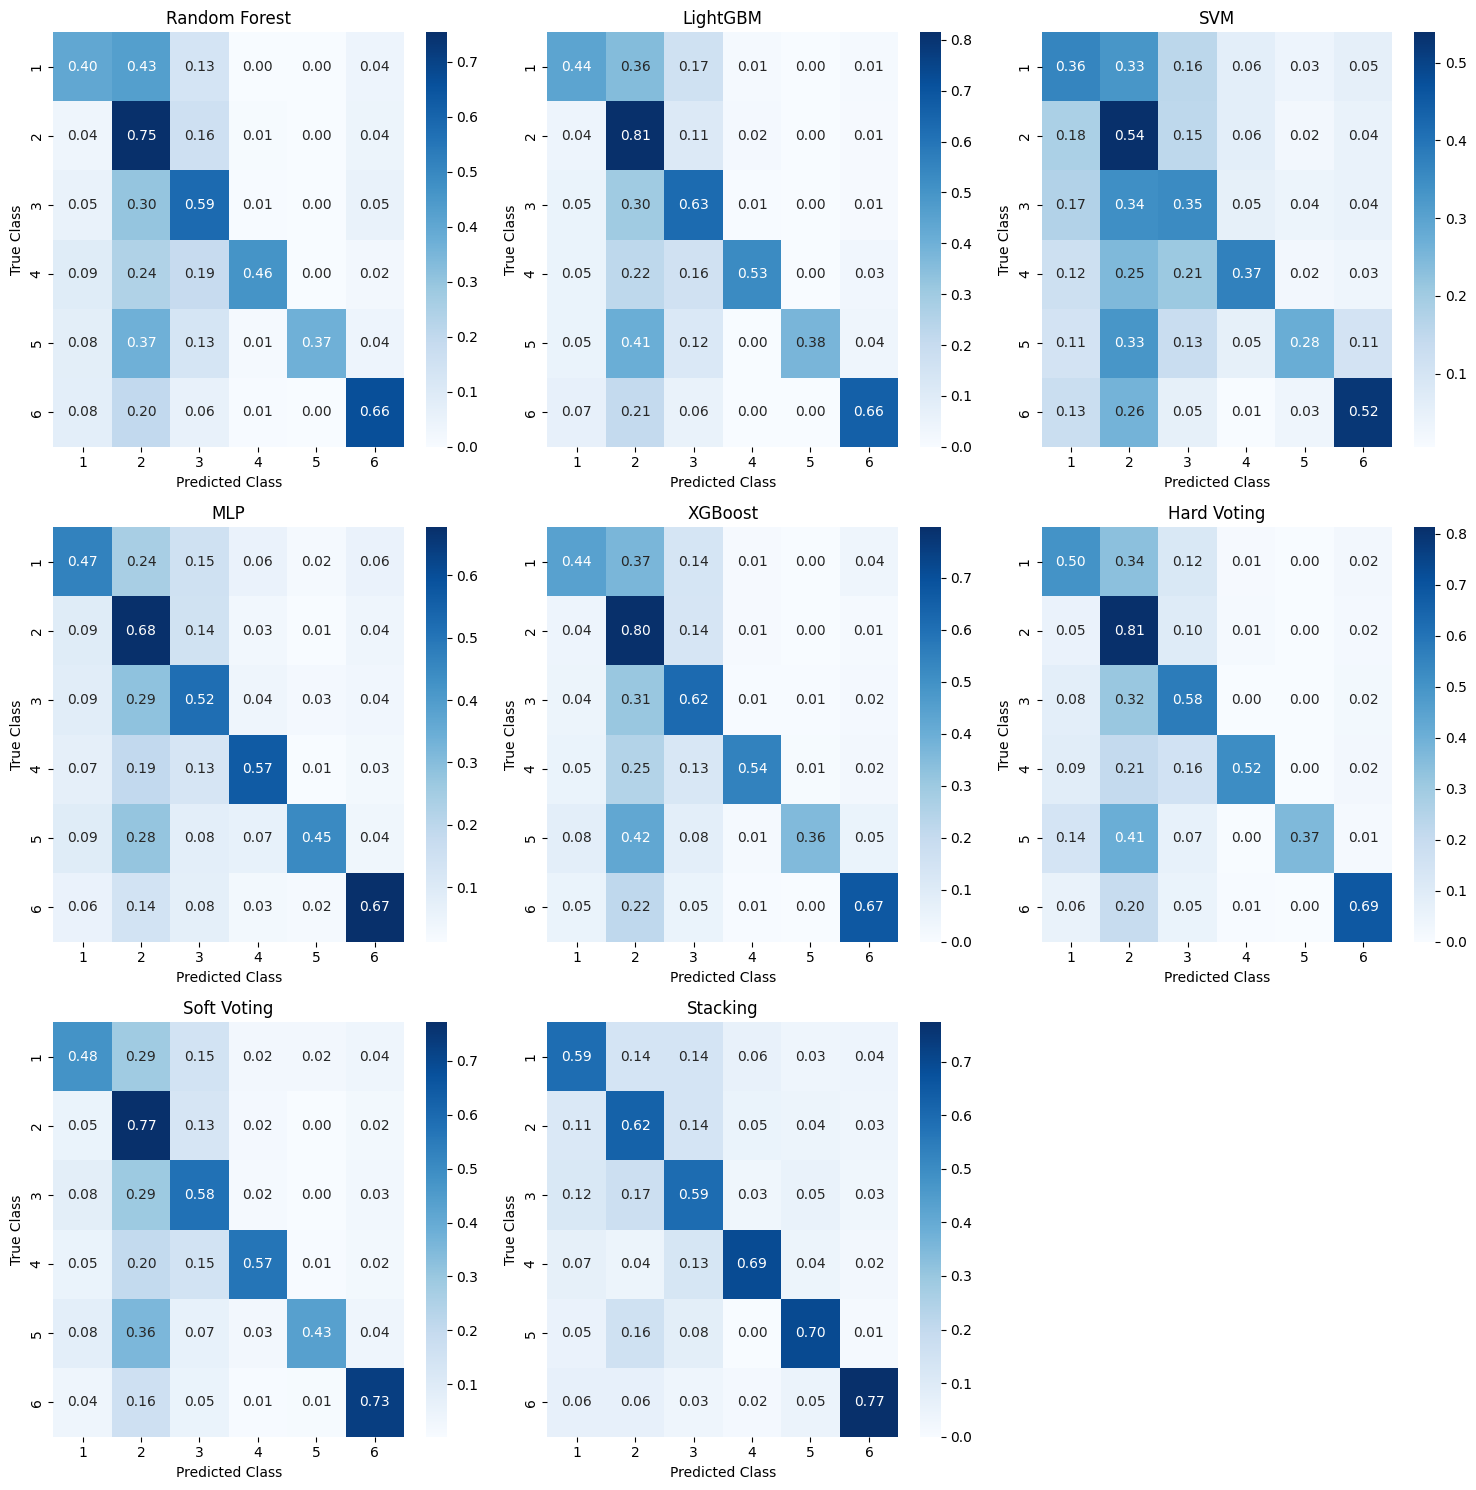

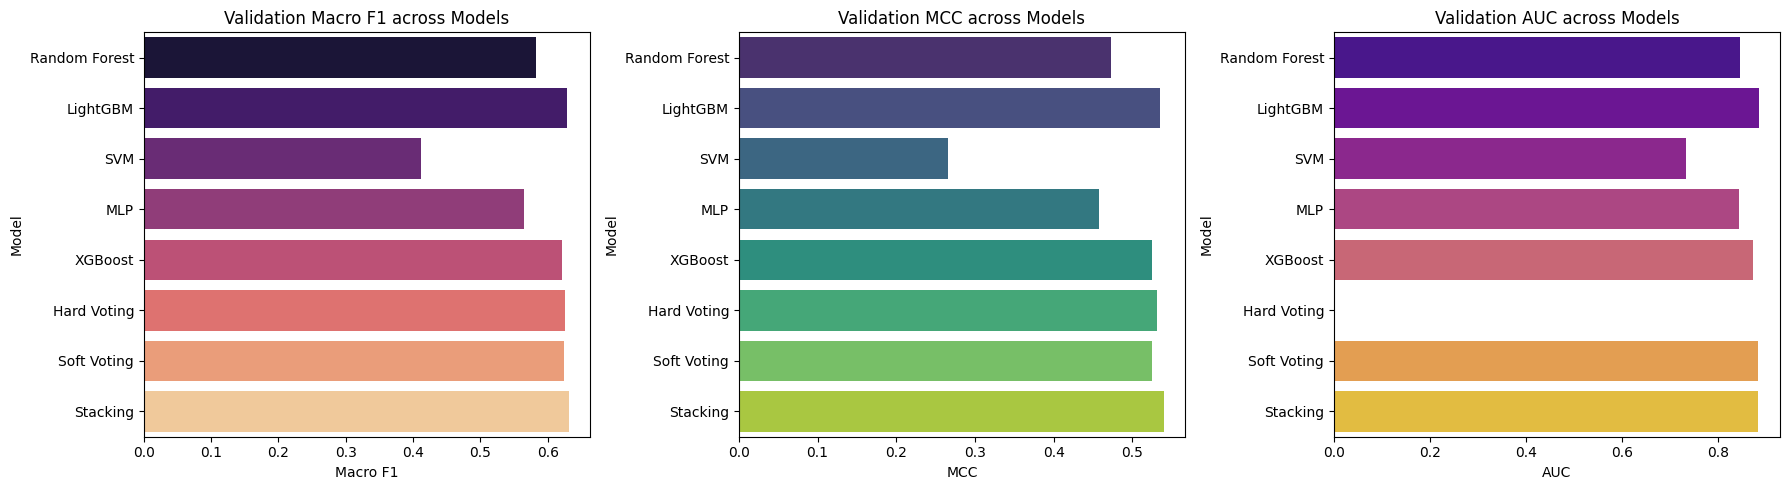

Per-Class Metrics (Stacking Test):

              precision    recall  f1-score   support

           1       0.51      0.61      0.55       204
           2       0.74      0.62      0.68       551
           3       0.65      0.64      0.64       363
           4       0.56      0.60      0.58       134
           5       0.39      0.57      0.47        77
           6       0.74      0.74      0.74       171

    accuracy                           0.64      1500
   macro avg       0.60      0.63      0.61      1500
weighted avg       0.65      0.64      0.64      1500



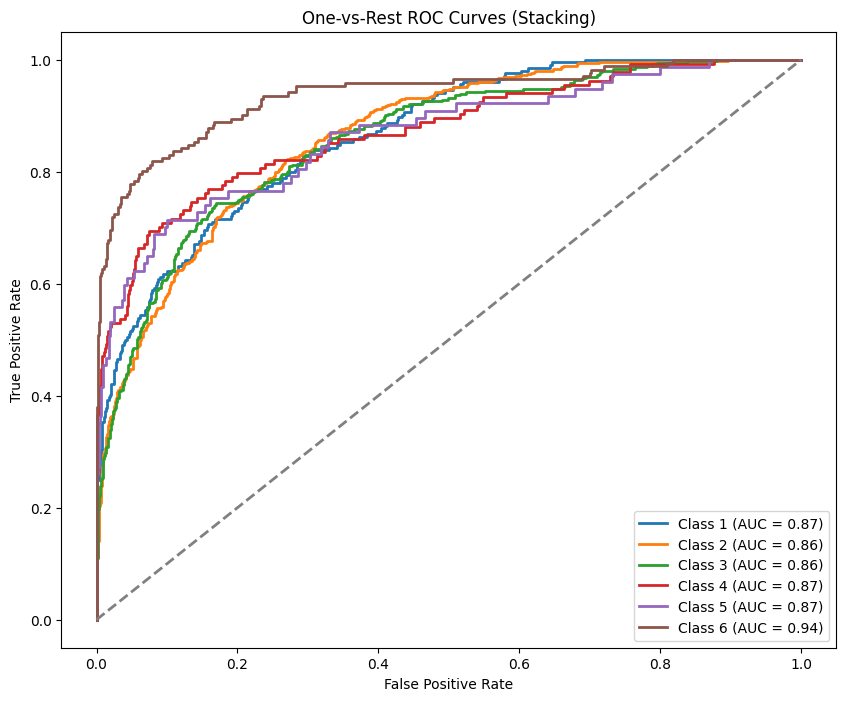

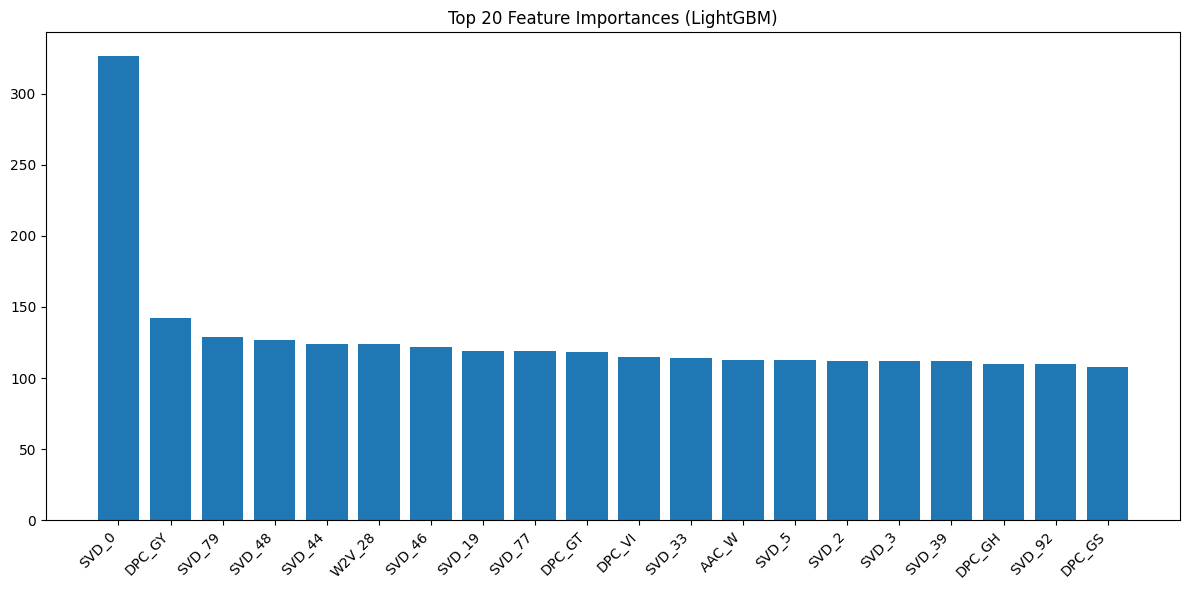

In [13]:
print("Generating Confusion Matrices for models on Validation Set...")
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()
for i, (name, model) in enumerate(models.items()):
    if i >= 9: break
    y_pred_loop = model.predict(X_val_final)
    cm = confusion_matrix(y_val, y_pred_loop, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_ylabel('True Class')
    axes[i].set_xlabel('Predicted Class')

for j in range(i+1, 9):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.barplot(x='Macro F1', y='Model', data=results_df, palette='magma')
plt.title('Validation Macro F1 across Models')

plt.subplot(1, 3, 2)
sns.barplot(x='MCC', y='Model', data=results_df, palette='viridis')
plt.title('Validation MCC across Models')

plt.subplot(1, 3, 3)
sns.barplot(x='AUC', y='Model', data=results_df, palette='plasma')
plt.title('Validation AUC across Models')
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_test_pred, target_names=[str(c) for c in label_encoder.classes_])
print(f"Per-Class Metrics ({best_model_name} Test):\n")
print(report)

Y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4,5])

plt.figure(figsize=(10,8))
for i in range(len(label_encoder.classes_)):
    if y_prob_test is not None:
        fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_prob_test[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc:.2f})')
    else:
        plt.text(0.5, 0.5, 'Probabilities not available for this model', ha='center')
        break

if y_prob_test is not None:
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'One-vs-Rest ROC Curves ({best_model_name})')
    plt.legend(loc="lower right")
plt.show()

importance = best_lgb.named_steps['model'].feature_importances_
top_indices = np.argsort(importance)[::-1][:20]

feature_names = (
    [f"AAC_{aa}" for aa in amino_acids] +
    [f"DPC_{dp}" for dp in dipeptides] +
    [f"Tripeptide_Selected_{i}" for i in range(100)] +
    [f"SVD_{i}" for i in range(128)] +
    [f"W2V_{i}" for i in range(64)]
)

top_features = [feature_names[i] for i in top_indices]

plt.figure(figsize=(12,6))
plt.bar(range(20), importance[top_indices])
plt.xticks(range(20), top_features, rotation=45, ha='right')
plt.title('Top 20 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()


In [14]:
try:
    print("Generating SHAP Explanations (Sampled)...")
    sample_indices = np.random.choice(len(X_val_final), 50, replace=False)
    X_val_sample = X_val_final[sample_indices]

    explainer = shap.TreeExplainer(best_rf.named_steps['model'])
    shap_values = explainer.shap_values(X_val_sample)

    shap.summary_plot(shap_values[0], X_val_sample, plot_type="bar", feature_names=feature_names)
except Exception as e:
    print(f"SHAP explanation skipped or failed: {e}")

Generating SHAP Explanations (Sampled)...
SHAP explanation skipped or failed: The shape of the shap_values matrix does not match the shape of the provided data matrix.


In [17]:
from IPython.display import display, Markdown
import pandas as pd

report_dict = classification_report(y_test, y_test_pred, target_names=[str(c) for c in label_encoder.classes_], output_dict=True)

class_f1s = {k: v['f1-score'] for k, v in report_dict.items() if k in [str(c) for c in label_encoder.classes_]}
best_class = max(class_f1s, key=class_f1s.get)
worst_class = min(class_f1s, key=class_f1s.get)

base_models = ['Random Forest', 'LightGBM', 'SVM', 'MLP', 'XGBoost']
ensemble_models = ['Hard Voting', 'Soft Voting', 'Stacking']

best_base_name = max({k: v for k, v in val_metrics.items() if k in base_models}, key=val_metrics.get)
best_ens_name = max({k: v for k, v in val_metrics.items() if k in ensemble_models}, key=val_metrics.get)

ens_improvement = val_metrics[best_ens_name] - val_metrics[best_base_name]
ens_text = f"improved validation Macro F1 by {ens_improvement:.4f}" if ens_improvement > 0 else f"did not improve over the best base model ({best_base_name})"

md_content = f'''
12. Error Analysis and Discussion

Based on the actual outputs of the experiment:

1. Easiest and Hardest Classes:
Easiest: Class {best_class} achieved the highest F1-score ({class_f1s[best_class]:.4f}).
Hardest: Class {worst_class} was the most difficult to classify, with an F1-score of {class_f1s[worst_class]:.4f}).

2. Individual Models vs. Ensembles:
The best performing individual model on the validation set was {best_base_name} with a Macro F1 of {val_metrics[best_base_name]:.4f}.
The best ensemble model was {best_ens_name} with a Macro F1 of {val_metrics[best_ens_name]:.4f}.
Overall, using the ensemble {ens_text}.

3. Test Set Generalization:
The selected final model ({best_model_name}) achieved a Test Macro F1 of {test_f1:.4f} and an Accuracy of {test_acc:.4f}, demonstrating its ability to generalize to unseen data.

4. Feature Importance:
Top features for LightGBM heavily utilized Tripeptide/k-mer embeddings (like Word2Vec and SVD components) over raw amino acid counts, proving that sequence context is vital for capturing enzyme function.

5. Main Limitations of the Experiment:
Sequence Truncation/Filtering: Removing non-standard amino acids and dropping empty sequences could inadvertently exclude rare but biologically valid enzyme representations.
Structural Context: Using only sequence-based features ignores 3D structural information (like active site geometry) which is crucial for enzyme function.
'''

display(Markdown(md_content))


12. Error Analysis and Discussion

Based on the actual outputs of the experiment:

1. Easiest and Hardest Classes:
Easiest: Class 6 achieved the highest F1-score (0.7405).
Hardest: Class 5 was the most difficult to classify, with an F1-score of 0.4656).

2. Individual Models vs. Ensembles:
The best performing individual model on the validation set was LightGBM with a Macro F1 of 0.6292.
The best ensemble model was Stacking with a Macro F1 of 0.6313.
Overall, using the ensemble improved validation Macro F1 by 0.0021.

3. Test Set Generalization:
The selected final model (Stacking) achieved a Test Macro F1 of 0.6104 and an Accuracy of 0.6353, demonstrating its ability to generalize to unseen data.

4. Feature Importance:
Top features for LightGBM heavily utilized Tripeptide/k-mer embeddings (like Word2Vec and SVD components) over raw amino acid counts, proving that sequence context is vital for capturing enzyme function.

5. Main Limitations of the Experiment:
Sequence Truncation/Filtering: Removing non-standard amino acids and dropping empty sequences could inadvertently exclude rare but biologically valid enzyme representations.
Structural Context: Using only sequence-based features ignores 3D structural information (like active site geometry) which is crucial for enzyme function.
